## Imports & Config

In [32]:
import importlib

from meta_heuristics import meta_information
from meta_heuristics import  problem_instance
from meta_heuristics import  solution_instance
from meta_heuristics import  swap_2_player
from meta_heuristics import  simulated_annealing
importlib.reload(meta_information)
importlib.reload(problem_instance)
importlib.reload(solution_instance)
importlib.reload(swap_2_player)
importlib.reload(simulated_annealing)

from meta_information import MetaInformationPlotter, MetaInformation
from problem_instance import ProblemInstance
from solution_instance import SolutionInstance
from swap_2_player import Swap2Player
from simulated_annealing import SimulatedAnnealing

import itertools
import time

# Social Golfer Problem Config
NUM_GROUPS = 6
NUM_PLAYERS = 32
NUM_WEEKS = 8

# Simulated Annealing Config
# INIT_TEMPS = [100, 200]
INIT_TEMPS = [50, 100, 200]
# ALPHAS = [0.85, 0.90]
ALPHAS = [0.95, 0.98, 0.99]
# EQI_ITERS = [10]
EQI_ITERS = [50, 70, 100]
FINAL_TEMP = 0.001

results = []

In [15]:
for alpha in ALPHAS:
    for init_temp in INIT_TEMPS:
        for eqi_iter in EQI_ITERS:
            problem = ProblemInstance(NUM_GROUPS, NUM_PLAYERS, NUM_WEEKS)
            neighborhood = Swap2Player()
            solution = SolutionInstance(problem, SolutionInstance.generate_random_solution, neighborhood)

            sa = SimulatedAnnealing(
                solution_inst=solution,
                init_temperature=init_temp,
                final_temperature=FINAL_TEMP,
                equilibrium_iterations=eqi_iter,
                alpha=alpha,
            )

            best_solution = sa.solve()
            meta_inf = sa.meta_inf
            meta_inf.label = f"T0={init_temp}, eqi={eqi_iter}"
            print(meta_inf.label)

            results.append((alpha, init_temp, eqi_iter, meta_inf))

print("Finished hyperparameter search!")

T0=50, eqi=50
T0=50, eqi=70
T0=50, eqi=100
T0=100, eqi=50
T0=100, eqi=70
T0=100, eqi=100
T0=200, eqi=50
T0=200, eqi=70
T0=200, eqi=100
T0=50, eqi=50
T0=50, eqi=70
T0=50, eqi=100
T0=100, eqi=50
T0=100, eqi=70
T0=100, eqi=100
T0=200, eqi=50
T0=200, eqi=70
T0=200, eqi=100
T0=50, eqi=50
T0=50, eqi=70
T0=50, eqi=100
T0=100, eqi=50
T0=100, eqi=70
T0=100, eqi=100
T0=200, eqi=50
T0=200, eqi=70
T0=200, eqi=100
Finished hyperparameter search!


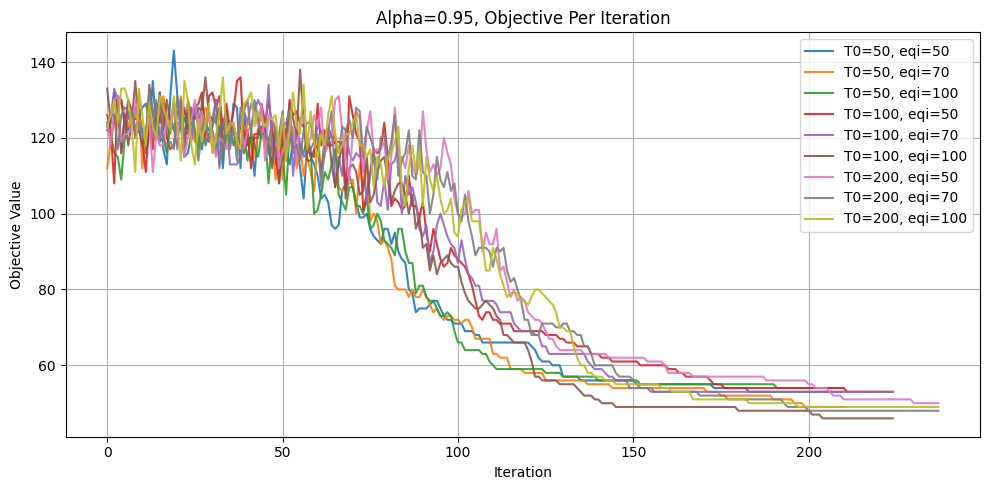

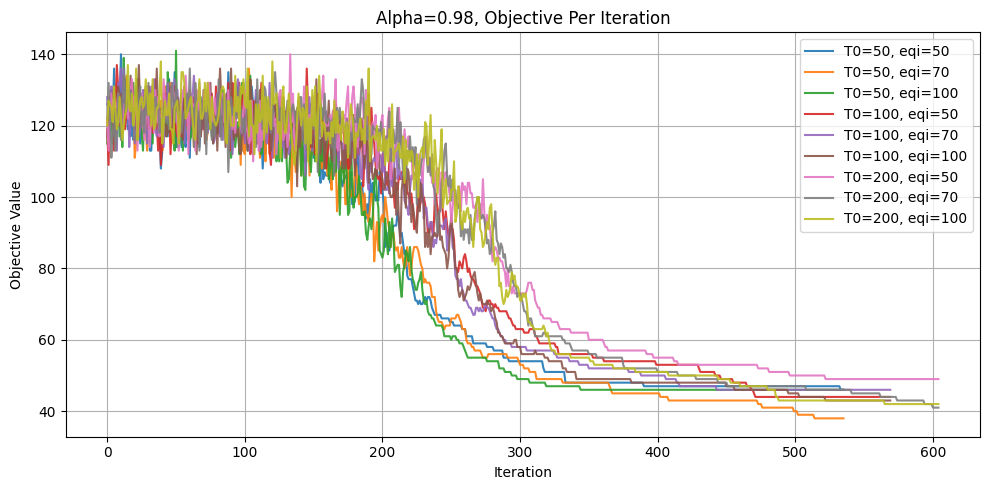

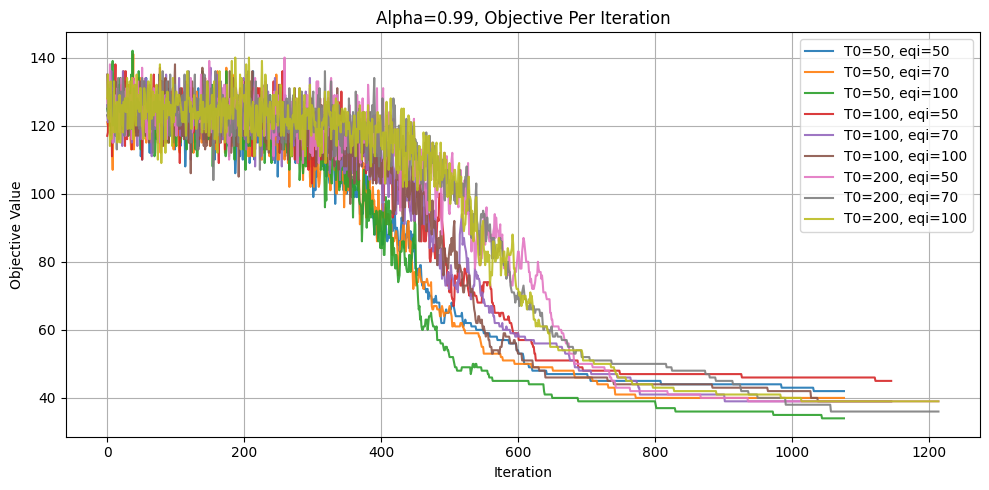

In [16]:
from collections import defaultdict

# group meta_infos by alpha
by_alpha = defaultdict(list)
for alpha, init_temp, eqi_iter, meta_inf in results:
    by_alpha[alpha].append(meta_inf)

# one figure per alpha, with multiple curves
for alpha, meta_infos in by_alpha.items():
    MetaInformationPlotter.plot_meta_info(meta_infos=meta_infos, title_prefix=f"Alpha={alpha}, ")

## Run Simulated Annealing

Violation Count: 116
Week 0:
  Group 0: [16, 19, 22, 29, 21]
  Group 1: [25, 2, 5, 13, 18]
  Group 2: [27, 31, 17, 24, 11]
  Group 3: [4, 14, 3, 15, 28]
  Group 4: [8, 0, 9, 6, 26]
  Group 5: [20, 10, 12, 23, 30]
Week 1:
  Group 0: [10, 26, 18, 1, 9]
  Group 1: [12, 5, 21, 23, 8]
  Group 2: [22, 31, 30, 19, 7]
  Group 3: [16, 2, 6, 29, 27]
  Group 4: [17, 11, 13, 25, 0]
  Group 5: [20, 28, 14, 15, 4]
Week 2:
  Group 0: [10, 22, 1, 2, 17]
  Group 1: [5, 3, 9, 31, 25]
  Group 2: [4, 26, 13, 12, 29]
  Group 3: [20, 21, 8, 7, 16]
  Group 4: [19, 0, 24, 15, 28]
  Group 5: [18, 27, 30, 6, 23]
Week 3:
  Group 0: [31, 28, 25, 17, 19]
  Group 1: [4, 22, 18, 8, 15]
  Group 2: [13, 10, 5, 20, 24]
  Group 3: [7, 21, 11, 30, 0]
  Group 4: [3, 6, 1, 16, 23]
  Group 5: [9, 2, 14, 27, 29]
Week 4:
  Group 0: [27, 8, 21, 17, 10]
  Group 1: [13, 26, 30, 18, 31]
  Group 2: [11, 0, 25, 12, 29]
  Group 3: [19, 6, 1, 20, 15]
  Group 4: [22, 16, 23, 3, 9]
  Group 5: [14, 5, 24, 4, 2]
Week 5:
  Group 0: [11, 1

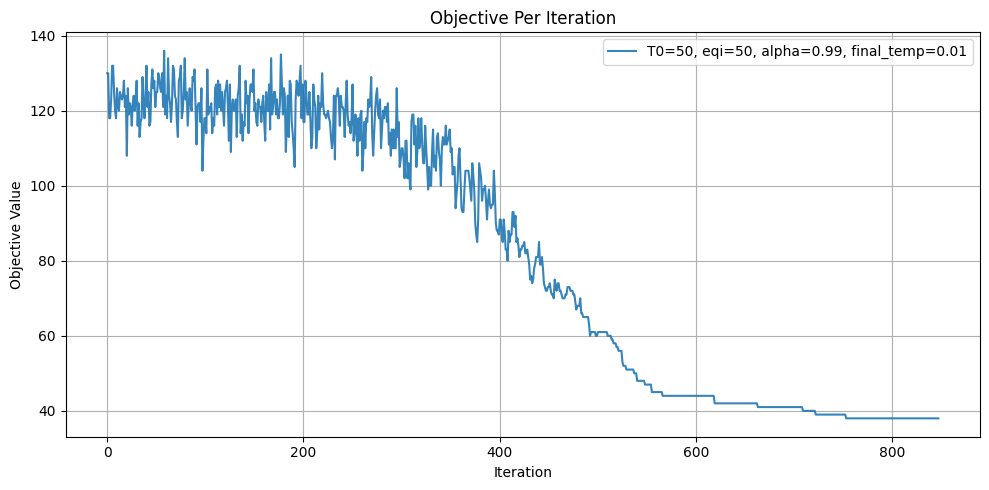

In [34]:
init_temp = 50
final_temp = 0.01
eqi_iter = 50
alpha =0.99

problem_instance = ProblemInstance(NUM_GROUPS,NUM_PLAYERS,NUM_WEEKS)
neighborhood = Swap2Player()
solution_instance = SolutionInstance(problem_instance, SolutionInstance.generate_random_solution, neighborhood)
print(solution_instance)
sa_solver = SimulatedAnnealing(
    solution_instance,
    init_temperature=init_temp,
    final_temperature=final_temp,
    equilibrium_iterations=eqi_iter,
    alpha=alpha)


meta_infos = []
best_solution = sa_solver.solve()
print(f"Best solution found with {best_solution.count_violations()} violations")
sa_solver.meta_inf.label=f"T0={init_temp}, eqi={eqi_iter}, alpha={alpha}, final_temp={final_temp}"
meta_infos.append(sa_solver.meta_inf)

MetaInformationPlotter.plot_meta_info(meta_infos=meta_infos)

In [ ]:
print("Hello world")